#  Notebook 02 — Prétraitement & Feature Engineering
**Projet : Prédiction du Churn Client | 4IASD**

---
**Objectifs :**
- Nettoyer le dataset (valeurs manquantes, types incorrects)
- Encoder les variables catégorielles
- Effectuer le feature engineering
- Appliquer le train/test split (80/20)
- Standardiser les variables numériques
- Sauvegarder le pipeline pour réutilisation

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print(' Imports OK')

 Imports OK


## 1. Chargement du Dataset

In [2]:
df = pd.read_csv('../data/telco_churn.csv')
print(f'Shape initiale : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape initiale : (7043, 21)
Colonnes : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Nettoyage des Données

### 2.1 Suppression de la colonne inutile

In [3]:
# customerID n'est pas une feature prédictive
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)
    print(' customerID supprimé')

print(f'Shape après suppression : {df.shape}')

 customerID supprimé
Shape après suppression : (7043, 20)


### 2.2 Correction du type de TotalCharges

In [4]:
print(f'Type actuel TotalCharges : {df["TotalCharges"].dtype}')
print(f'Exemples de valeurs : {df["TotalCharges"].head(5).tolist()}')

# Conversion en numérique (les espaces vides deviennent NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

n_missing = df['TotalCharges'].isnull().sum()
print(f'\n→ Valeurs manquantes créées : {n_missing}')
print(f'Type après conversion : {df["TotalCharges"].dtype}')

Type actuel TotalCharges : object
Exemples de valeurs : ['29.85', '1889.5', '108.15', '1840.75', '151.65']

→ Valeurs manquantes créées : 11
Type après conversion : float64


### 2.3 Gestion des valeurs manquantes

In [5]:
# Afficher les lignes avec TotalCharges manquant
missing_rows = df[df['TotalCharges'].isnull()]
print(f'Lignes avec TotalCharges manquant : {len(missing_rows)}')
if len(missing_rows) > 0:
    print('\nAperçu (tenure = 0 → clients nouveaux sans charges) :')
    print(missing_rows[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head())

# Stratégie : tenure=0 → TotalCharges = 0 logiquement
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f'\n Valeurs manquantes après correction : {df["TotalCharges"].isnull().sum()}')

Lignes avec TotalCharges manquant : 11

Aperçu (tenure = 0 → clients nouveaux sans charges) :
      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No

 Valeurs manquantes après correction : 0


### 2.4 Vérification finale des valeurs manquantes

In [6]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

if missing_summary.empty:
    print(' Aucune valeur manquante dans le dataset.')
else:
    print(' Valeurs manquantes restantes :')
    print(missing_summary)

 Aucune valeur manquante dans le dataset.


### 2.5 Encodage de la variable cible

In [7]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'Distribution de la cible encodée :')
print(df['Churn'].value_counts())
print(f'\nTaux de churn : {df["Churn"].mean()*100:.1f}%')

Distribution de la cible encodée :
Churn
0    5174
1    1869
Name: count, dtype: int64

Taux de churn : 26.5%


## 3. Feature Engineering

In [8]:
# --- Feature 1 : Nombre de services souscrits ---
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_cols].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)

# --- Feature 2 : Ratio charges mensuelles / tenure ---
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)  # +1 pour éviter division par 0

# --- Feature 3 : Flag client senior sans partenaire (profil vulnérable) ---
df['senior_alone'] = ((df['SeniorCitizen'] == 1) & (df['Partner'] == 'No')).astype(int)

# --- Feature 4 : Flag contrat court (risque élevé) ---
df['is_monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)

# --- Feature 5 : Flag internet haut débit sans sécurité ---
df['fiber_no_security'] = (
    (df['InternetService'] == 'Fiber optic') &
    (df['OnlineSecurity'] == 'No')
).astype(int)

print(' Features engineered :')
print('   - num_services         : nombre de services souscrits')
print('   - charges_per_tenure   : frais mensuels / (tenure + 1)')
print('   - senior_alone         : client senior sans partenaire')
print('   - is_monthly_contract  : contrat mensuel (0/1)')
print('   - fiber_no_security    : fiber optic sans sécurité en ligne')
print(f'\nShape après feature engineering : {df.shape}')

 Features engineered :
   - num_services         : nombre de services souscrits
   - charges_per_tenure   : frais mensuels / (tenure + 1)
   - senior_alone         : client senior sans partenaire
   - is_monthly_contract  : contrat mensuel (0/1)
   - fiber_no_security    : fiber optic sans sécurité en ligne

Shape après feature engineering : (7043, 25)


### Validation des nouvelles features

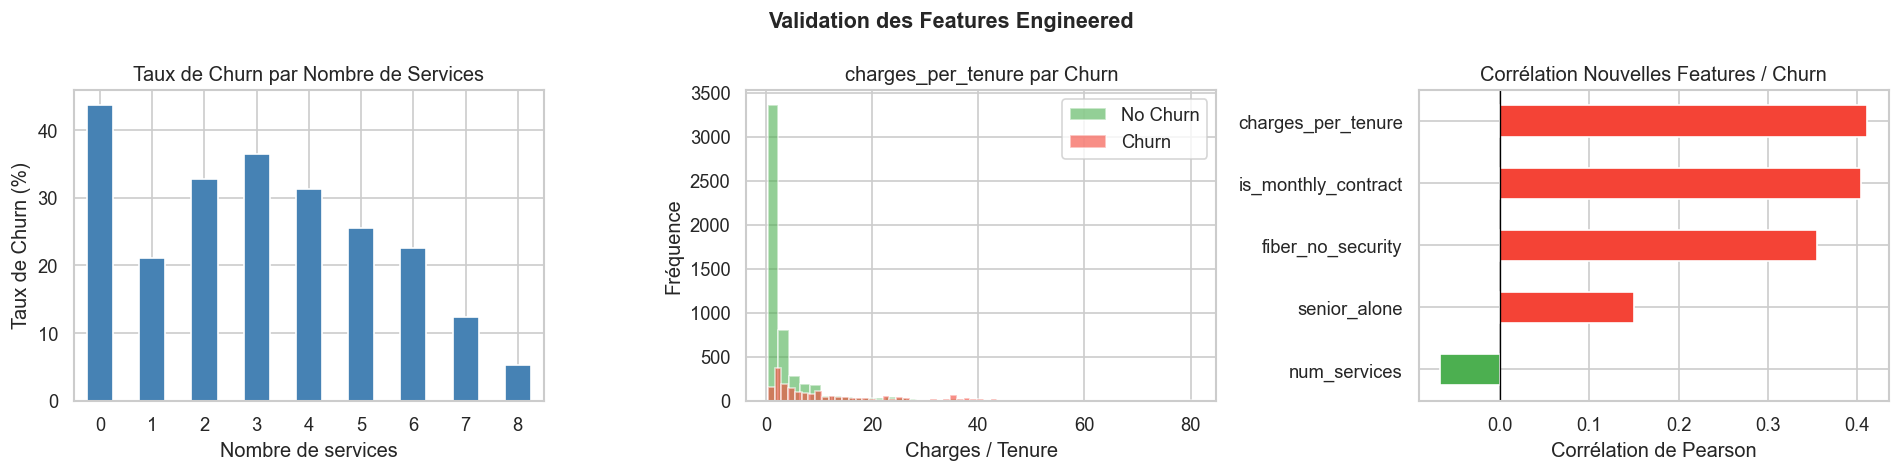

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# num_services vs churn
churn_by_services = df.groupby('num_services')['Churn'].mean() * 100
churn_by_services.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Taux de Churn par Nombre de Services')
axes[0].set_ylabel('Taux de Churn (%)')
axes[0].set_xlabel('Nombre de services')
axes[0].tick_params(axis='x', rotation=0)

# charges_per_tenure vs churn
for churn_val, color, label in zip([0, 1], ['#4CAF50', '#F44336'], ['No Churn', 'Churn']):
    axes[1].hist(df[df['Churn'] == churn_val]['charges_per_tenure'],
                 bins=40, alpha=0.6, color=color, label=label)
axes[1].set_title('charges_per_tenure par Churn')
axes[1].set_xlabel('Charges / Tenure')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

# Correlation des nouvelles features avec churn
new_features = ['num_services', 'charges_per_tenure', 'senior_alone',
                'is_monthly_contract', 'fiber_no_security']
corr_new = df[new_features + ['Churn']].corr()['Churn'].drop('Churn').sort_values()
corr_new.plot(kind='barh', ax=axes[2], color=['#F44336' if v > 0 else '#4CAF50' for v in corr_new])
axes[2].set_title('Corrélation Nouvelles Features / Churn')
axes[2].set_xlabel('Corrélation de Pearson')
axes[2].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Validation des Features Engineered', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/feature_engineering_validation.png')
plt.show()

## 4. Encodage des Variables Catégorielles

In [10]:
# Identifier les colonnes catégorielles restantes
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables catégorielles à encoder ({len(cat_cols)}) :')
for col in cat_cols:
    print(f'   {col} : {df[col].unique()}')

Variables catégorielles à encoder (15) :
   gender : ['Female' 'Male']
   Partner : ['Yes' 'No']
   Dependents : ['No' 'Yes']
   PhoneService : ['No' 'Yes']
   MultipleLines : ['No phone service' 'No' 'Yes']
   InternetService : ['DSL' 'Fiber optic' 'No']
   OnlineSecurity : ['No' 'Yes' 'No internet service']
   OnlineBackup : ['Yes' 'No' 'No internet service']
   DeviceProtection : ['No' 'Yes' 'No internet service']
   TechSupport : ['No' 'Yes' 'No internet service']
   StreamingTV : ['No' 'Yes' 'No internet service']
   StreamingMovies : ['No' 'Yes' 'No internet service']
   Contract : ['Month-to-month' 'One year' 'Two year']
   PaperlessBilling : ['Yes' 'No']
   PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [11]:
# Colonnes binaires Yes/No → 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

print(f' Colonnes binaires encodées : {binary_cols}')

# Colonnes multi-valeurs → Label Encoding
# (adapté pour XGBoost/CatBoost qui gèrent bien ce format)
multi_cols = ['gender', 'MultipleLines', 'InternetService',
              'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

le = LabelEncoder()
label_encoders = {}

for col in multi_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f'   {col} encodé → {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\n Toutes les variables catégorielles encodées')
print(f'Shape : {df.shape}')

 Colonnes binaires encodées : ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
   gender encodé → {'Female': 0, 'Male': 1}
   MultipleLines encodé → {'No': 0, 'No phone service': 1, 'Yes': 2}
   InternetService encodé → {'DSL': 0, 'Fiber optic': 1, 'No': 2}
   OnlineSecurity encodé → {'No': 0, 'No internet service': 1, 'Yes': 2}
   OnlineBackup encodé → {'No': 0, 'No internet service': 1, 'Yes': 2}
   DeviceProtection encodé → {'No': 0, 'No internet service': 1, 'Yes': 2}
   TechSupport encodé → {'No': 0, 'No internet service': 1, 'Yes': 2}
   StreamingTV encodé → {'No': 0, 'No internet service': 1, 'Yes': 2}
   StreamingMovies encodé → {'No': 0, 'No internet service': 1, 'Yes': 2}
   Contract encodé → {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
   PaymentMethod encodé → {'Bank transfer (automatic)': 0, 'Credit card (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3}

 Toutes les variables catégorielles encodées
Shape : (7043, 25)


### Vérification — plus de variables object

In [12]:
remaining_cat = df.select_dtypes(include='object').columns.tolist()
if not remaining_cat:
    print(' Aucune variable catégorielle restante — dataset 100% numérique')
else:
    print(f' Variables restantes à encoder : {remaining_cat}')

df.dtypes

 Aucune variable catégorielle restante — dataset 100% numérique


gender                   int32
SeniorCitizen            int64
Partner                  int64
Dependents               int64
tenure                   int64
PhoneService             int64
MultipleLines            int32
InternetService          int32
OnlineSecurity           int32
OnlineBackup             int32
DeviceProtection         int32
TechSupport              int32
StreamingTV              int32
StreamingMovies          int32
Contract                 int32
PaperlessBilling         int64
PaymentMethod            int32
MonthlyCharges         float64
TotalCharges           float64
Churn                    int64
num_services             int64
charges_per_tenure     float64
senior_alone             int32
is_monthly_contract      int32
fiber_no_security        int32
dtype: object

## 5. Séparation Features / Cible

In [13]:
X = df.drop(columns=['Churn'])
y = df['Churn']

feature_names = X.columns.tolist()

print(f'Features (X) : {X.shape[1]} colonnes')
print(f'Cible (y)    : {y.shape[0]} observations')
print(f'\nListe des features :')
for i, f in enumerate(feature_names):
    print(f'   {i+1:2d}. {f}')

Features (X) : 24 colonnes
Cible (y)    : 7043 observations

Liste des features :
    1. gender
    2. SeniorCitizen
    3. Partner
    4. Dependents
    5. tenure
    6. PhoneService
    7. MultipleLines
    8. InternetService
    9. OnlineSecurity
   10. OnlineBackup
   11. DeviceProtection
   12. TechSupport
   13. StreamingTV
   14. StreamingMovies
   15. Contract
   16. PaperlessBilling
   17. PaymentMethod
   18. MonthlyCharges
   19. TotalCharges
   20. num_services
   21. charges_per_tenure
   22. senior_alone
   23. is_monthly_contract
   24. fiber_no_security


## 6. Train / Test Split (80% / 20%)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # important : préserver le ratio de churn dans chaque split
)

print('=== Train / Test Split ===')
print(f'  X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print()
print('=== Vérification du ratio Churn (stratification) ===')
print(f'  Train — Churn rate : {y_train.mean()*100:.1f}%')
print(f'  Test  — Churn rate : {y_test.mean()*100:.1f}%')
print(f'  Global — Churn rate : {y.mean()*100:.1f}%')

=== Train / Test Split ===
  X_train : (5634, 24)  |  y_train : (5634,)
  X_test  : (1409, 24)   |  y_test  : (1409,)

=== Vérification du ratio Churn (stratification) ===
  Train — Churn rate : 26.5%
  Test  — Churn rate : 26.5%
  Global — Churn rate : 26.5%


### Visualisation du split

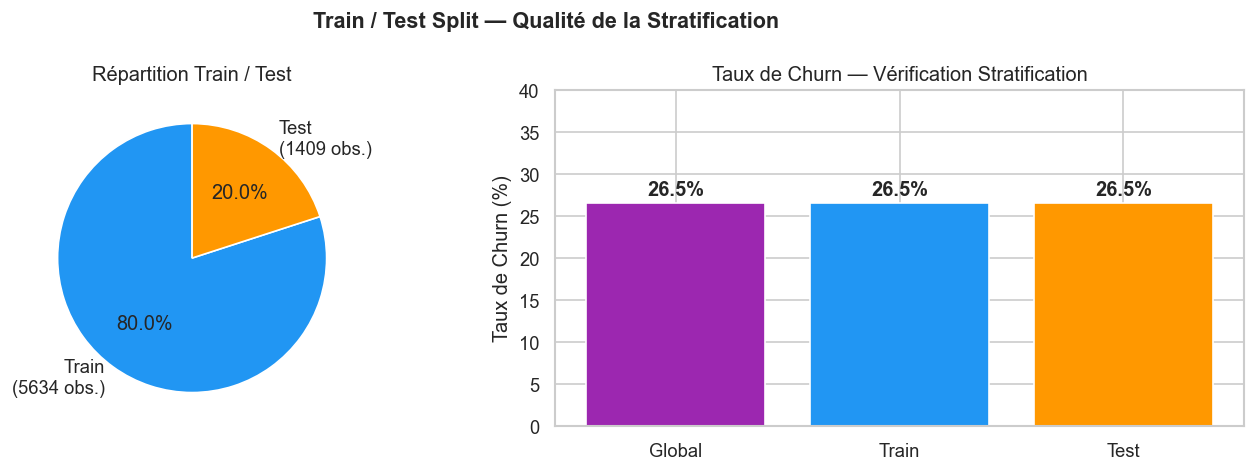

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Répartition train/test
sizes = [len(X_train), len(X_test)]
labels = [f'Train\n({len(X_train)} obs.)', f'Test\n({len(X_test)} obs.)']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#2196F3', '#FF9800'], startangle=90)
axes[0].set_title('Répartition Train / Test')

# Taux de churn train vs test (stratification)
churn_rates = {
    'Global': y.mean() * 100,
    'Train': y_train.mean() * 100,
    'Test': y_test.mean() * 100
}
bars = axes[1].bar(churn_rates.keys(), churn_rates.values(),
                   color=['#9C27B0', '#2196F3', '#FF9800'], edgecolor='white')
axes[1].set_title('Taux de Churn — Vérification Stratification')
axes[1].set_ylabel('Taux de Churn (%)')
axes[1].set_ylim(0, 40)
for bar, val in zip(bars, churn_rates.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Train / Test Split — Qualité de la Stratification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/train_test_split.png')
plt.show()

## 7. Standardisation (StandardScaler)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform seulement, pas fit_transform !

# Reconvertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

print(' StandardScaler appliqué')
print(f'   Fit sur X_train uniquement (éviter la fuite de données)')
print(f'   Transform appliqué sur X_train et X_test')
print()
print('Moyennes après scaling (doivent être ≈ 0 sur train) :')
print(X_train_scaled[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(4))

 StandardScaler appliqué
   Fit sur X_train uniquement (éviter la fuite de données)
   Transform appliqué sur X_train et X_test

Moyennes après scaling (doivent être ≈ 0 sur train) :
tenure           -0.0
MonthlyCharges   -0.0
TotalCharges      0.0
dtype: float64


### Visualisation avant / après standardisation

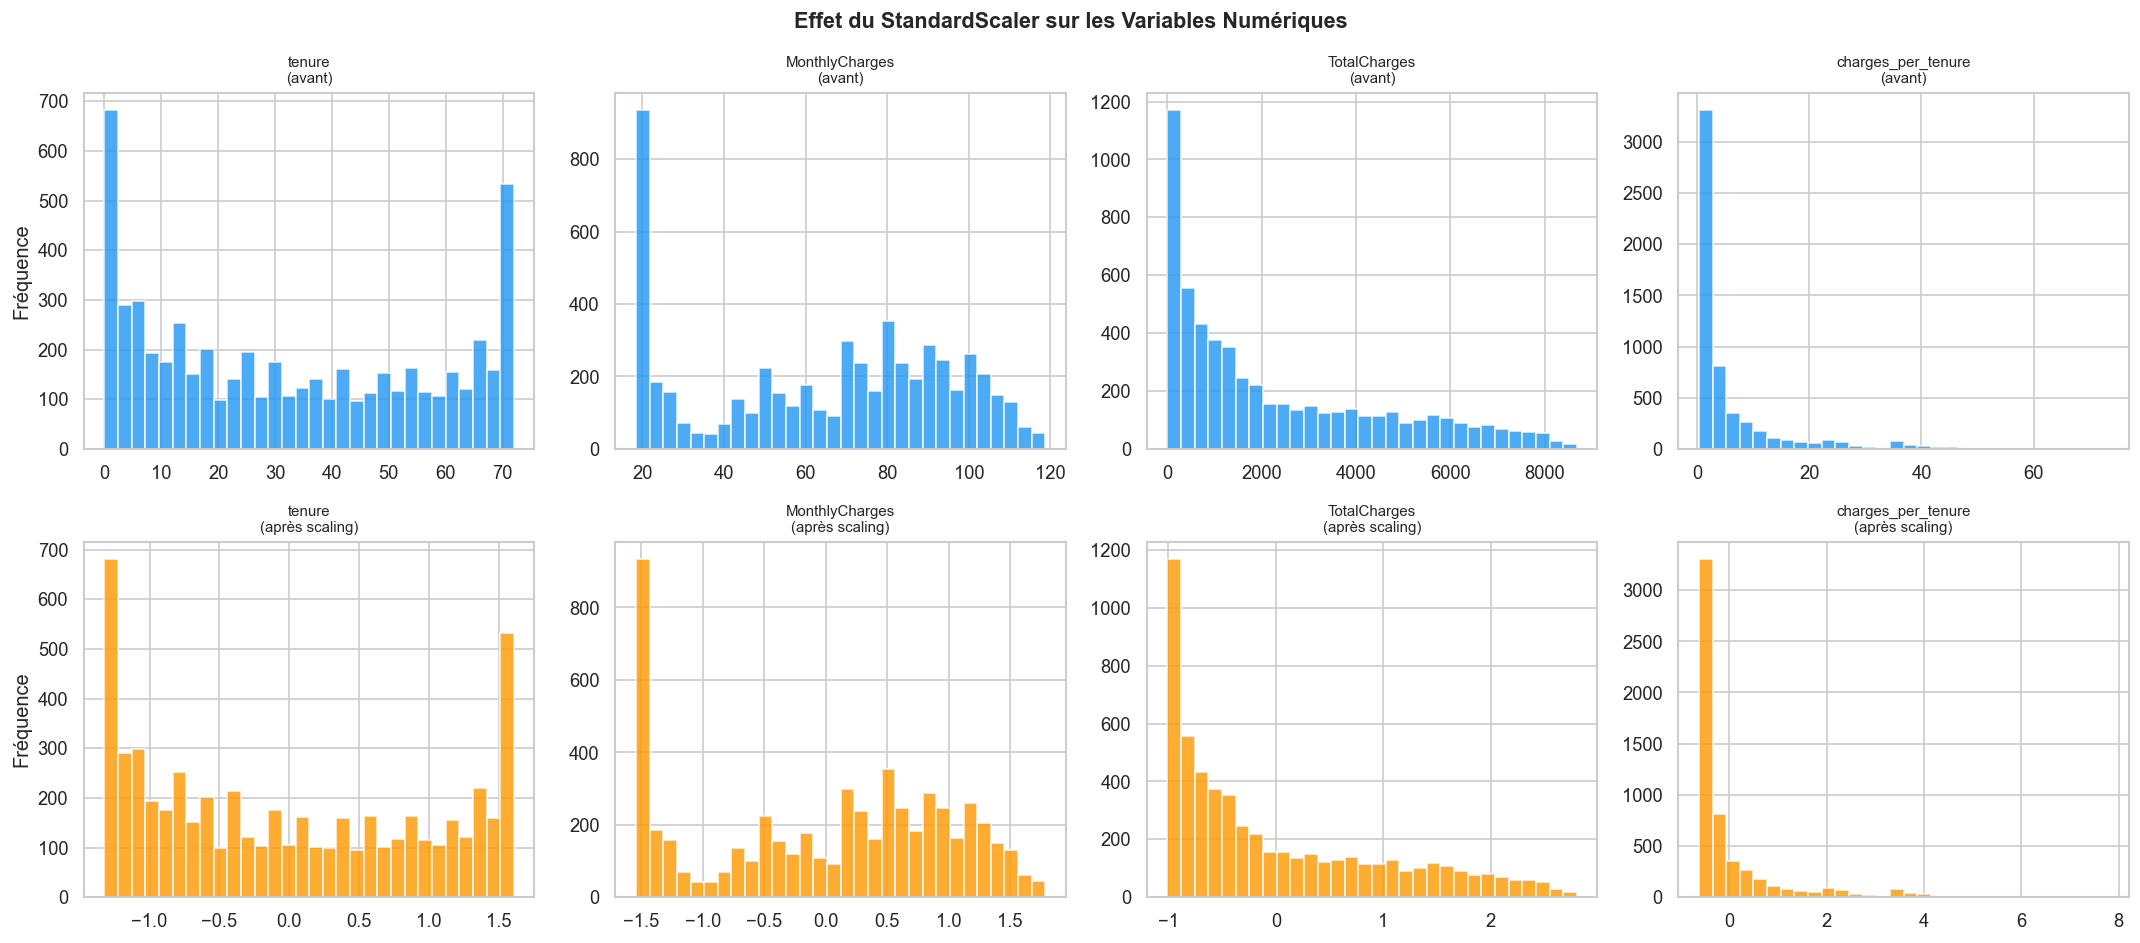

In [17]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_features):
    # Avant
    axes[0, i].hist(X_train[col], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(avant)', fontsize=9)
    axes[0, i].set_ylabel('Fréquence' if i == 0 else '')

    # Après
    axes[1, i].hist(X_train_scaled[col], bins=30, color='#FF9800', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(après scaling)', fontsize=9)
    axes[1, i].set_ylabel('Fréquence' if i == 0 else '')

plt.suptitle('Effet du StandardScaler sur les Variables Numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/scaling_effect.png')
plt.show()

## 8. Sauvegarde du Pipeline

In [18]:
import os
os.makedirs('../models', exist_ok=True)

# Scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Noms des features
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Label encoders
with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Sauvegarder les sets prétraités pour réutilisation dans notebook 03
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
X_train_scaled.to_csv('../data/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/X_test_scaled.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print(' Pipeline sauvegardé :')
print('   models/scaler.pkl')
print('   models/feature_names.pkl')
print('   models/label_encoders.pkl')
print('   data/X_train.csv, X_test.csv')
print('   data/X_train_scaled.csv, X_test_scaled.csv')
print('   data/y_train.csv, y_test.csv')

 Pipeline sauvegardé :
   models/scaler.pkl
   models/feature_names.pkl
   models/label_encoders.pkl
   data/X_train.csv, X_test.csv
   data/X_train_scaled.csv, X_test_scaled.csv
   data/y_train.csv, y_test.csv


## 9. Résumé du Pipeline de Prétraitement

In [19]:
print('='*60)
print('    RÉSUMÉ DU PIPELINE DE PRÉTRAITEMENT')
print('='*60)
print()
print('1. NETTOYAGE')
print('    Suppression customerID (non prédictif)')
print('    TotalCharges → numérique (pd.to_numeric)')
print('    Valeurs manquantes TotalCharges → 0 (tenure=0)')
print()
print('2. FEATURE ENGINEERING')
print('    num_services         (0–8)')
print('    charges_per_tenure   (ratio)')
print('    senior_alone         (binaire)')
print('    is_monthly_contract  (binaire)')
print('    fiber_no_security    (binaire)')
print()
print('3. ENCODAGE')
print('    Variable cible : Yes→1 / No→0')
print('    Colonnes binaires : Yes/No → 1/0')
print('    Colonnes multi-valeurs : LabelEncoder')
print()
print('4. SPLIT')
print(f'    Train : {len(X_train)} obs. | Test : {len(X_test)} obs.')
print(f'    Stratifié — Churn rate train={y_train.mean()*100:.1f}% / test={y_test.mean()*100:.1f}%')
print()
print('5. STANDARDISATION')
print('    StandardScaler fit sur X_train uniquement')
print(f'    {X_train_scaled.shape[1]} features standardisées')
print()
print(f'Shape finale — X_train : {X_train_scaled.shape} | X_test : {X_test_scaled.shape}')
print('='*60)

    RÉSUMÉ DU PIPELINE DE PRÉTRAITEMENT

1. NETTOYAGE
    Suppression customerID (non prédictif)
    TotalCharges → numérique (pd.to_numeric)
    Valeurs manquantes TotalCharges → 0 (tenure=0)

2. FEATURE ENGINEERING
    num_services         (0–8)
    charges_per_tenure   (ratio)
    senior_alone         (binaire)
    is_monthly_contract  (binaire)
    fiber_no_security    (binaire)

3. ENCODAGE
    Variable cible : Yes→1 / No→0
    Colonnes binaires : Yes/No → 1/0
    Colonnes multi-valeurs : LabelEncoder

4. SPLIT
    Train : 5634 obs. | Test : 1409 obs.
    Stratifié — Churn rate train=26.5% / test=26.5%

5. STANDARDISATION
    StandardScaler fit sur X_train uniquement
    24 features standardisées

Shape finale — X_train : (5634, 24) | X_test : (1409, 24)


---
## ✅ Conclusion

Le pipeline de prétraitement est complet et sauvegardé. Le dataset est prêt pour l'entraînement des modèles.

| Étape | Statut |
|-------|--------|
| Nettoyage & types | ✅ |
| Valeurs manquantes | ✅ |
| Feature engineering (5 nouvelles features) | ✅ |
| Encodage catégoriel | ✅ |
| Train/Test split stratifié 80/20 | ✅ |
| Standardisation (StandardScaler) | ✅ |
| Sauvegarde pipeline (.pkl + .csv) | ✅ |

→ **Prochaine étape** : `03_experiments.ipynb` — Entraînement & Évaluation des modèles